# Homework 4: The Bootstrap

BEE 4850/5850, Fall 2025

**Name**:

**ID**:

> **Due Date**
>
> Friday, 3/28/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice simulation-based
uncertainty quantification, focusing on the bootstrap.

-   Problem 1 asks you to use the non-parametric bootstrap to estimate
    uncertainty in a Poisson regression model.
-   Problem 2 asks you to use the bootstrap (through resampling
    residuals) to estimate uncertainty in a semi-empirical sea-level
    rise model.
-   Problem 3 (only required for students in BEE 5850) asks you to use a
    moving block bootstrap to estimate the sampling distribution of the
    median of extreme water level data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
# import Pkg
# Pkg.activate(@__DIR__)
# Pkg.instantiate()

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
# using Random # random number generation and seed-setting
# using DataFrames # tabular data structure
# using DataFramesMeta # API which can simplify chains of DataFrames transformations
# using CSV # reads/writes .csv files
# using Distributions # interface to work with probability distributions
# using Plots # plotting library
# using StatsBase # statistical quantities like mean, median, etc
# using StatsPlots # some additional statistical plotting tools

In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
from scipy.stats import pearsonr
from scipy.stats import bernoulli, beta, binom, lognorm, uniform
import math
from scipy.optimize import minimize
import random
import seaborn as sns
from scipy.stats import poisson
from scipy.stats import norm

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Revisit the salamander model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html), using
percent groundcover as a predictor in the Poisson regression. Use the
non-parametric bootstrap to estimate bias and confidence intervals for
the model parameters.

**In this problem**:

-   Load the data from `data/salamanders.csv`.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Use 1,000 non-parametric bootstrap samples to obtain estimates of
    bias and the 90% confidence interval for the intercept and
    coefficient in the Poisson regression.

As in homework 2, I load the dataset and normalize the columns. Then I develop a function salaman_model which takes the parameters and the data for the percentage of ground cover and salamander count, uses a link function, develops a poisson model, and calculates the log likelihood. I then minimize the negative of the log likelihood in order to fit the model parameters β_0 and β_1.

I create a function, salam_boot_sample, which draws a given number of random samples from the data, with replacement, which I use to draw 1,000 samples. Next, I fit the model for each sample in the same manner as I did for the original data, minimizing the negative of the log likelihood, in order to get values for β_0 and β_1 for each sample. I take the mean of these values across the different samples. I estimate the bias from the β_0 and β_1 from the original sample and the mean bootstrapped values using the formula. I use the percentile bootstrap confidence interval to calculate 90% confidence interval for the intercept and coefficient in the Poisson regression.


In [4]:
data_dir = os.path.join("data", "salamanders.csv")
salamander_data = pd.read_csv(data_dir, index_col='SITE')

In [5]:
col = 'PCTCOVER'
salamander_data[col] = (salamander_data[col] - salamander_data[col].mean())/salamander_data[col].std()

col = 'FORESTAGE'
salamander_data[col] = (salamander_data[col] - salamander_data[col].mean())/salamander_data[col].std()

In [6]:
def salaman_model(params, pctcover, salaman_data):
    β_0, β_1 = params
    λ = np.exp(β_0 + β_1 * pctcover)
    loglik = np.sum(poisson.logpmf(salaman_data, λ))
    return loglik

In [7]:
lb = [-100.0, -100.0]
ub = [100.0, 100.0]
init = [0.0, 0.0]

result = minimize(lambda θ: -salaman_model(θ, salamander_data['PCTCOVER'], salamander_data['SALAMAN']), init, bounds=list(zip(lb, ub)))
θ_mle = result.x
print(np.round(θ_mle, decimals=5))

[0.42951 1.15951]


In [8]:
x = np.arange(salamander_data['PCTCOVER'].min(), salamander_data['PCTCOVER'].max(),0.01)

In [9]:
β_0 = θ_mle[0]
β_1 = θ_mle[1]
λ = np.exp(β_0 + β_1 * x)

In [10]:
percent_90 = np.zeros(len(λ))
lower_90 = np.zeros(len(λ))
means = np.zeros(len(λ))
for i in range(len(λ)):
    r = poisson.rvs(λ[i], size=100000)
    percent_90[i] = np.quantile(r,  0.95, axis=0)
    lower_90[i] = np.quantile(r,  0.05, axis=0)
    means[i] = np.quantile(r,  0.5, axis=0)

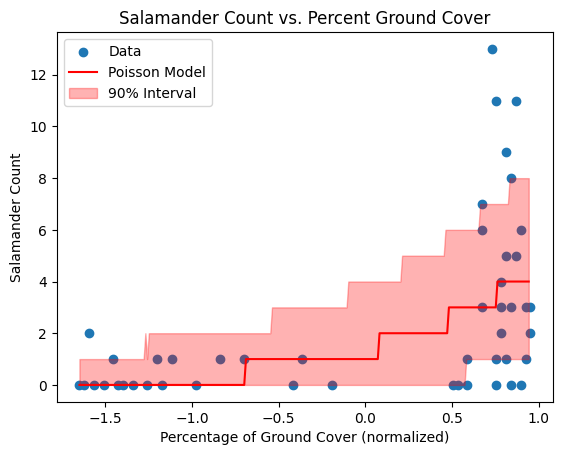

In [11]:
plt.scatter(salamander_data['PCTCOVER'], salamander_data['SALAMAN'])
# plt.plot(x, λ, color = 'orange')
plt.plot(x, means, color = 'red')
plt.fill_between(x, lower_90, percent_90, color='red', alpha=0.3, label = '90% Interval')
plt.ylabel("Salamander Count")
plt.xlabel("Percentage of Ground Cover (normalized)")
plt.title("Salamander Count vs. Percent Ground Cover")
plt.legend(['Data','Poisson Model','90% Interval' ])

In [12]:
# bootstrap: draw new samples
def salam_boot_sample(dat,i):
    boot_sample = dat.sample(n=len(dat), random_state=i, replace=True)
    return boot_sample

def salam_boot_freq(dat, nsamp):
    intercept = np.zeros(nsamp)
    coefficient = np.zeros(nsamp)
    for i in range (nsamp):
        boot_freq = salam_boot_sample(dat,i)
        result = minimize(lambda θ: -salaman_model(θ, boot_freq['PCTCOVER'], boot_freq['SALAMAN']), init, bounds=list(zip(lb, ub)))
        intercept[i] = result.x[0]
        coefficient[i] = result.x[1]
    return intercept, coefficient
    


intercept, coefficient = salam_boot_freq(salamander_data, 1000)


In [13]:
β_0
β_1
mean_boot_intercept = intercept.mean()
mean_boot_coef = coefficient.mean()
bias_β_0 = β_0 -  mean_boot_intercept
bias_β_1 = β_1 -  mean_boot_coef
β_0_bias_corrected = β_0 + bias_β_0
β_1_bias_corrected =  β_1 + bias_β_1


In [14]:
β_0_bias_corrected

np.float64(0.4642171184382953)

In [15]:
q_boot_intercept = 2 * β_0 - np.quantile(intercept, [0.975, 0.025])

In [16]:
q_boot_coefficient = 2 * β_1 - np.quantile(coefficient, [0.975, 0.025])

In [90]:
q_boot_coefficient 

array([0.54310162, 1.5361499 ])

For the intercept, the bias is about 0.205, and the bias corrected estimate is about 0.8052. The 90% confidence interval is about [0.44202563, 1.29778254].

For the coefficient, the bias is about -0.0373, and the bias corrected estimate is about 1.122. The 90% confidence interval is about [0.54310162, 1.5361499].



### Problem 2

Revisit the sea-level rise model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html):

$$\begin{aligned}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{aligned}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

We would like to quantify uncertainty in the model parameters using the
bootstrap.

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data and
    include an initial sea-level parameter $S_0$. This will be similar
    to the model from Homework 2. Fit this model to the data with AR(1)
    residuals.
-   Use your fitted model and the AR(1) residual process to generate
    1,000 parametric bootstrap samples. Refit the model to each. Plot
    histograms of the bootstrap samples for each parameter. What is the
    90% confidence interval for the sensitivity of sea level to global
    mean temperature?


As in HW 2, I load the datasets and create a model to simulate the sea-level rise using discretization. I minimize the negative of the log likelihood in order to fit the model with parameters, including the model error term. For this homework, I fit the residuals to an AR1 model using the whitening method.

In [94]:
# Load data

data_dir = os.path.join("data", "HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv")
gmt_data = pd.read_csv(data_dir, index_col = 'Time')
gmt_data['Anomaly (deg C)'] = gmt_data['Anomaly (deg C)'] - gmt_data.loc[1980:1999,:]['Anomaly (deg C)'].mean()
gmt_data.loc[1980:1999,:]['Anomaly (deg C)'].mean()
data_dir = os.path.join("data", "CSIRO_Recons_gmsl_yr_2015.csv")
gmsa_data = pd.read_csv(data_dir, index_col = 'Time')
# gmsa_data = pd.read_csv(data_dir)
gmsa_data.index = gmsa_data.index-0.5
gmsa_data['GMSL (mm)'] = gmsa_data['GMSL (mm)'] - gmsa_data.loc[1980:1999,:]['GMSL (mm)'].mean()
gmsa_data.loc[1980:1999,:]['GMSL (mm)'].mean()
gmt_data = gmt_data.drop(gmt_data.index.difference(gmsa_data.index))
len(gmt_data)

134

In [95]:
Seq = np.zeros(len(gmt_data))
def sim_gmsl(S_0, gmta_data, response_time, a, b):
    Seq = np.zeros(len(gmta_data))
    S = np.zeros(len(gmta_data))
    S[0] = S_0
        
    for i in range(0,len(gmta_data)-1):
        Seq[i] = a*gmta_data.iloc[i] + b
        S[i+1] = S[i] + (Seq[i]-S[i])/response_time
    
    return(S)
        

In [96]:
def gmsl_loglik(params, gmsl_data, gmta_data, gmsl_error):
    S_0, response_time, a, b, σ  = params  # unpack parameter vector
    y = sim_gmsl(S_0, gmta_data, response_time, a, b)
    ll = np.sum(norm.logpdf(gmsl_data, loc=y, scale=np.sqrt(σ**2+gmsl_error**2)))  # compute log-likelihood
    return ll

In [97]:
params = [1,1,1,1,1,0.5]
gmsl_data = gmsa_data['GMSL (mm)']
gmta_data = gmt_data['Anomaly (deg C)']
gmsl_error = gmsa_data['GMSL uncertainty (mm)']
S_0, response_time, a, b, σ, ρ  = params  # unpack parameter vector
gmsl_sim = sim_gmsl(S_0, gmta_data, response_time, a, b)
residuals = (gmsl_data - gmsl_sim).values


In [98]:
T = len(gmsl_data)
ll = 0  # initialize log-likelihood counter
for t in range(len(gmsl_error)):
    if t == 0:
        ll += norm.logpdf(residuals[0], loc=0, scale=np.sqrt(σ**2 / (1 - ρ**2) + gmsl_error.values[0]**2))
    else:
        resid_wn = residuals[t] - ρ * residuals[t-1]
        ll += norm.logpdf(resid_wn, loc=0, scale=np.sqrt(σ**2 + gmsl_error.values[t]**2))

In [99]:
def gmsl_loglik(params, gmsl_data, gmta_data, gmsl_error):
    S_0, response_time, a, b, σ, ρ  = params  # unpack parameter vector
    gmsl_sim = sim_gmsl(S_0, gmta_data, response_time, a, b)
    residuals = (gmsl_data - gmsl_sim).values
    # ll = np.sum(norm.logpdf(gmsl_data, loc=y, scale=np.sqrt(σ**2+gmsl_error**2)))  # compute log-likelihood
    T = len(gmsl_data)
    ll = 0  # initialize log-likelihood counter
    for t in range(len(gmsl_error)):
        if t == 0:
            ll += norm.logpdf(residuals[0], loc=0, scale=np.sqrt(σ**2 / (1 - ρ**2) + gmsl_error.values[0]**2))
        else:
            resid_wn = residuals[t] - ρ * residuals[t-1]
            ll += norm.logpdf(resid_wn, loc=0, scale=np.sqrt(σ**2 + gmsl_error.values[t]**2))

    return ll



In [100]:
lb = [-10000.0, 0.1, -1000.0,-1000.0,  0.01,  -0.9999]
ub = [0.0, 10000.0, 10000.0,1000.0,  1000.0,  0.9999]
p0 = [-160, 208.0, 1290.0, 770.0, 0.5, 0.5]

optim_out = minimize(lambda params: -gmsl_loglik(params, gmsa_data['GMSL (mm)'], gmt_data['Anomaly (deg C)'], gmsa_data['GMSL uncertainty (mm)']), p0, bounds=list(zip(lb, ub)))
p_mle = np.round(optim_out.x)

print(p_mle)
# θ_ar = optim_out.minimizer
θ_ar = optim_out.x

[-157.  147.  505.  345.    0.    1.]


In [101]:
sim_out = sim_gmsl(p_mle[0], gmt_data['Anomaly (deg C)'], p_mle[1], p_mle[2], p_mle[3])
sim_out = pd.Series(data = sim_out, index = gmt_data.index)

In [102]:
θ_ar[4]

np.float64(0.01)

In [103]:
θ_ar[-2]

np.float64(0.01)

In [104]:
θ_ar[5]

np.float64(0.5350645027323772)

In [105]:
θ_ar[-1]

np.float64(0.5350645027323772)

In [106]:
np.random.seed(42)
n = 1
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar2 = np.zeros((len(gmsl_error), n))
for t in range(len(gmsl_error)):
    if t == 0:
        residuals_ar2[t, :] = np.random.normal(0, np.sqrt(θ_ar[-2]**2 / (1 - θ_ar[-1]**2) + gmsl_error.values[0]**2), n)
    else:
        residuals_ar2[t, :] = θ_ar[-1] * residuals_ar2[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[-2]**2 + gmsl_error.values[t]**2), n)


In [107]:
np.random.seed(42)
n = 1
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar = np.zeros((len(gmsl_error), n))
for t in range(len(gmsl_error)):
    if t == 0:
        residuals_ar[t, :] = np.random.normal(0, np.sqrt(θ_ar[4]**2 / (1 - θ_ar[5]**2) + gmsl_error.values[0]**2), n)
    else:
        residuals_ar[t, :] = θ_ar[5] * residuals_ar[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[4]**2 + gmsl_error.values[t]**2), n)


In [108]:
all(residuals_ar2 == residuals_ar)

True

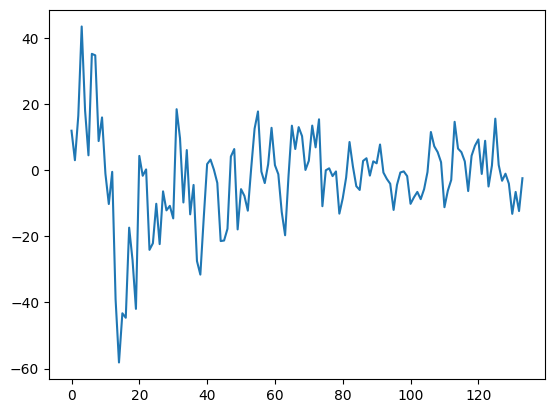

In [109]:
plt.plot(residuals_ar)
plt.savefig('residuals_plot.png')

In [110]:
n = 1
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar = np.zeros((len(gmsl_error), n))
for t in range(len(gmsl_error)):
    if t == 0:
        residuals_ar[t, :] = np.random.normal(0, np.sqrt(θ_ar[-2]**2 / (1 - θ_ar[-1]**2) + gmsl_error.values[0]**2), n)
    else:
        residuals_ar[t, :] = θ_ar[-1] * residuals_ar[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[-2]**2 + gmsl_error.values[t]**2), n)


In [111]:
n = 1000
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar = np.zeros((len(gmsl_error), n))
for t in range(len(gmsl_error)):
    if t == 0:
        residuals_ar[t, :] = np.random.normal(0, np.sqrt(θ_ar[-2]**2 / (1 - θ_ar[-1]**2) + gmsl_error.values[0]**2), n)
    else:
        residuals_ar[t, :] = θ_ar[-1] * residuals_ar[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[-2]**2 + gmsl_error.values[t]**2), n)


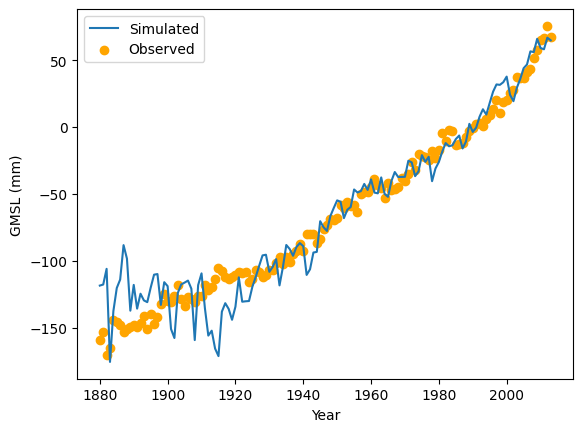

In [112]:
(sim_out+ residuals_ar[:,14]).plot()
# sim_out.plot()
plt.scatter(gmsa_data['GMSL (mm)'].index, gmsa_data['GMSL (mm)'].values, color = 'orange')
plt.xlabel('Year')
plt.ylabel('GMSL (mm)')
plt.legend(['Simulated', 'Observed'])

-   Use your fitted model and the AR(1) residual process to generate
    1,000 parametric bootstrap samples. Refit the model to each. Plot
    histograms of the bootstrap samples for each parameter. What is the
    90% confidence interval for the sensitivity of sea level to global
    mean temperature?

I use the whitening code to simulate AR1 residuals for each year 1000 times. I add these to the simulated data to create 1,000 parametric bootstrap samples. I plot the distribution for each parameter and fit the model on each of these samples and record the parameters for the fitted model for each. I calculate the bias and 90% percentile bootstrap confidence interval from these.

In [113]:
n = 1000
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar = np.zeros((len(gmsl_error), n))
for t in range(len(gmsl_error)):
    if t == 0:
        residuals_ar[t, :] = np.random.normal(0, np.sqrt(θ_ar[-2]**2 / (1 - θ_ar[-1]**2) + gmsl_error.values[0]**2), n)
    else:
        residuals_ar[t, :] = θ_ar[-2] * residuals_ar[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[-2]**2 + gmsl_error.values[t]**2), n)


In [114]:
boot_params = np.zeros((n, len(params)))
for iter in range(n):
    optim_out = minimize(lambda params: -gmsl_loglik(params, (sim_out+ residuals_ar[:, iter]), gmt_data['Anomaly (deg C)'], gmsa_data['GMSL uncertainty (mm)']), p0, bounds=list(zip(lb, ub)))
    boot_params[iter, :] = optim_out.x

KeyboardInterrupt: 

In [ ]:
pd.DataFrame(boot_params).to_csv('boot_params_results.csv')

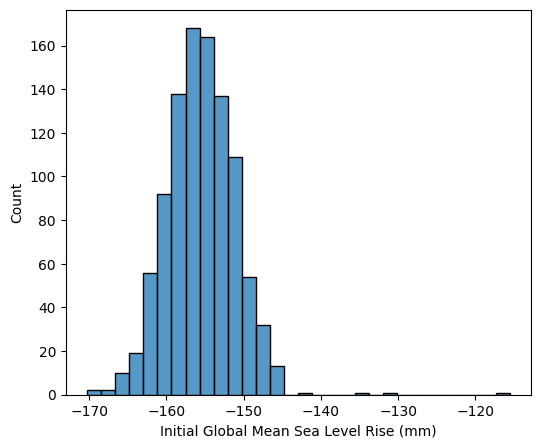

In [ ]:
# Histogram of residuals
plt.figure(figsize=(6, 5))
sns.histplot(boot_params[:, 0], bins=30)
plt.xlabel("Initial Global Mean Sea Level Rise (mm)")
plt.ylabel("Count")
plt.show()

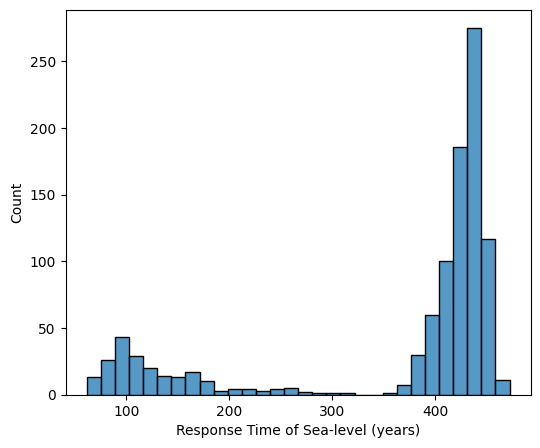

In [ ]:
# Histogram of residuals
plt.figure(figsize=(6, 5))
sns.histplot(boot_params[:, 1], bins=30)
plt.xlabel("Response Time of Sea-level (years)")
plt.ylabel("Count")
plt.show()

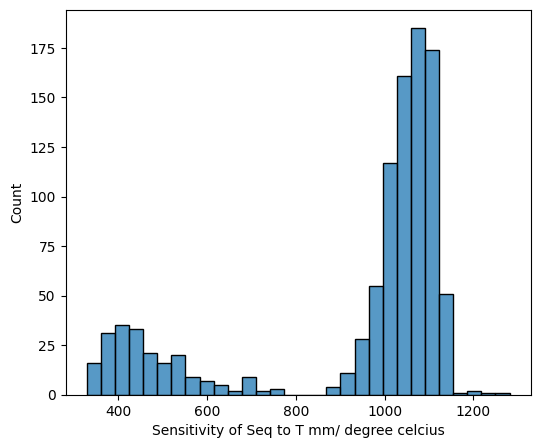

In [ ]:
# Histogram of residuals
plt.figure(figsize=(6, 5))
sns.histplot(boot_params[:, 2], bins=30)
plt.xlabel("Sensitivity of Seq to T mm/ degree celcius")
plt.ylabel("Count")
plt.show()

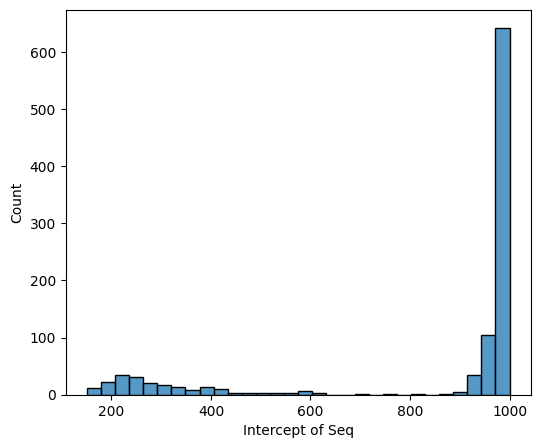

In [ ]:
# Histogram of residuals
plt.figure(figsize=(6, 5))
sns.histplot(boot_params[:, 3], bins=30)
plt.xlabel("Intercept of Seq")
plt.ylabel("Count")
plt.show()

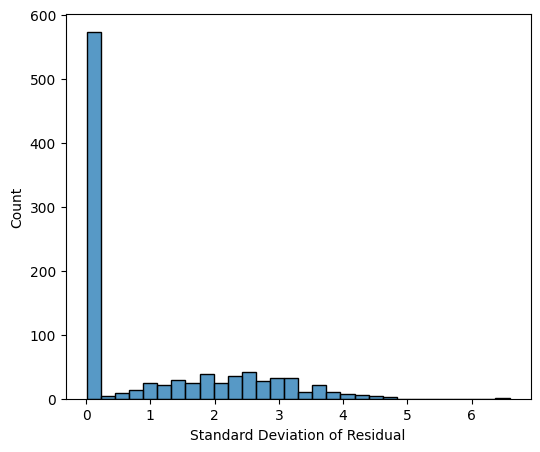

In [ ]:
# Histogram of residuals
plt.figure(figsize=(6, 5))
sns.histplot(boot_params[:, 4], bins=30)
plt.xlabel("Standard Deviation of Residual")
plt.ylabel("Count")
plt.show()

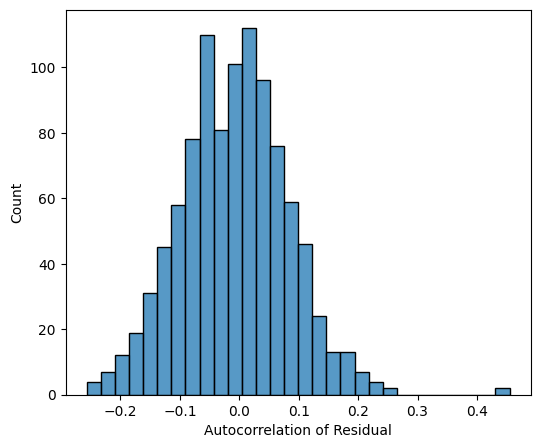

In [ ]:
# Histogram of residuals
plt.figure(figsize=(6, 5))
sns.histplot(boot_params[:, 5], bins=30)
plt.xlabel("Autocorrelation of Residual")
plt.ylabel("Count")
plt.show()

In [ ]:
q_boot_coefficient = 2 * p_mle[2] - np.quantile(boot_params[:, 2], [0.975, 0.025])

The 90% confidence interval for the sensitivity of sea level to global mean temperature is [-125.08350666,  636.41570625].

### Problem 3

Let’s revisit the 2015 Sewell’s Point tide gauge data, which consists of
hourly observations and predicted sea-level based on NOAA’s harmonic
model.

In [ ]:
function load_data(fname)
    date_format = "yyyy-mm-dd HH:MM"
    # this uses the DataFramesMeta package -- it's pretty cool
    return @chain fname begin
        CSV.File(; dateformat=date_format)
        DataFrame
        rename(
            "Time (GMT)" => "time", "Predicted (m)" => "harmonic", "Verified (m)" => "gauge"
        )
        @transform :datetime = (Date.(:Date, "yyyy/mm/dd") + Time.(:time))
        select(:datetime, :gauge, :harmonic)
        @transform :weather = :gauge - :harmonic
        @transform :month = (month.(:datetime))
    end
end

dat = load_data("data/norfolk-hourly-surge-2015.csv")

plot(dat.datetime, dat.gauge; ylabel="Gauge Measurement (m)", label="Observed", legend=:topleft, xlabel="Date/Time", color=:blue)
plot!(dat.datetime, dat.harmonic, label="Prediction", color=:orange)

We detrend the data to isolate the weather-induced variability by
subtracting the predictions from the observations; the results
(following the Julia code) are in `dat[:, :weather]`.

In [ ]:
plot(dat.datetime, dat.weather; ylabel="Gauge Weather Variability (m)", label="Detrended Data", linewidth=1, legend=:topleft, xlabel="Date/Time")

We would like to understand the uncertainty in an estimate of the median
sea level.

**In this problem**:

-   Construct 1,000 bootstrap replicates by adding a moving block
    bootstrap replicate from the weather-induced variability series
    (with block length 20) to the harmonic prediction. Use these
    replicates to compute a 90% confidence interval. What is the bias of
    the estimator?
-   Repeat the analysis with block length 50. How does this affect the
    confidence intervals and estimate of bias?
-   Why do you think using different block lengths produced the results
    that they did?

In [ ]:

def load_data(fname):
    date_format = "%Y-%m-%d %H:%M"
    df = pd.read_csv(fname, parse_dates=["Date"], date_parser=lambda x: pd.to_datetime(x))
    df.rename(columns={"Time (GMT)": "time", "Predicted (m)": "harmonic", "Verified (m)": "gauge"}, inplace=True)
    df['datetime'] = pd.to_datetime(df['Date'].dt.strftime('%Y/%m/%d') + ' ' + df['time'])
    df['weather'] = df['gauge'] - df['harmonic']
    df['month'] = df['datetime'].dt.month
    return df[['datetime', 'gauge', 'harmonic', 'weather', 'month']]


In [ ]:

dat = load_data("data/norfolk-hourly-surge-2015.csv")



C:\Users\fenya\AppData\Local\Temp\ipykernel_3756\2445974874.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(fname, parse_dates=["Date"], date_parser=lambda x: pd.to_datetime(x))


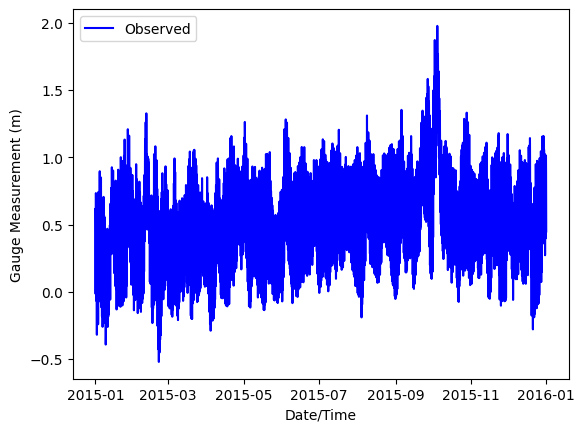

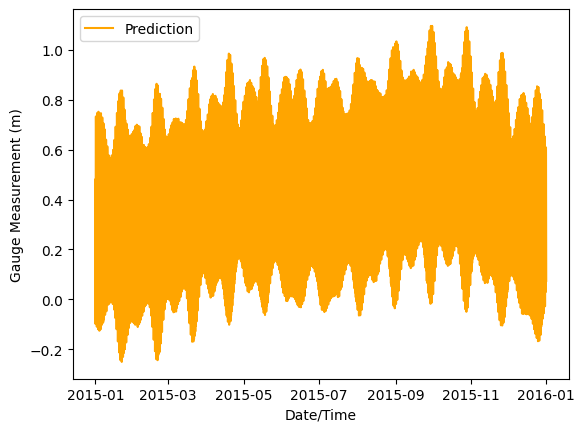

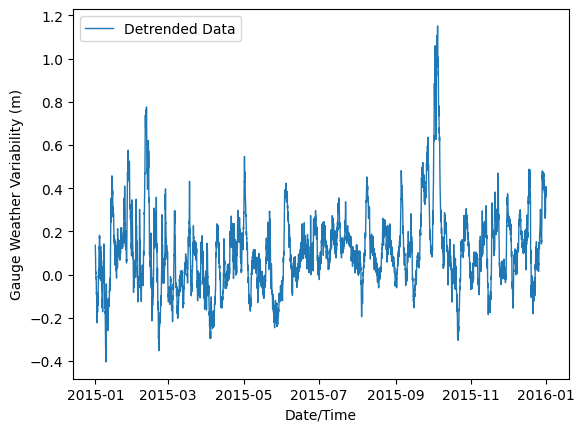

In [ ]:
plt.figure()
plt.plot(dat['datetime'], dat['gauge'], label="Observed", color='blue')
plt.ylabel("Gauge Measurement (m)")
plt.xlabel("Date/Time")
plt.legend(loc='upper left')
plt.show()

plt.figure()
plt.plot(dat['datetime'], dat['harmonic'], label="Prediction", color='orange')
plt.ylabel("Gauge Measurement (m)")
plt.xlabel("Date/Time")
plt.legend(loc='upper left')
plt.show()

plt.figure()
plt.plot(dat['datetime'], dat['weather'], label="Detrended Data", linewidth=1)
plt.ylabel("Gauge Weather Variability (m)")
plt.xlabel("Date/Time")
plt.legend(loc='upper left')
plt.show()

In [ ]:
# k is length of block
k = 20
n_blocks = len(dat['weather']) - k + 1
blocks = np.zeros([k, n_blocks])
for i in range(n_blocks):
    blocks[:, i] = dat['weather'][i:(k+i)]

blocks[:, 1:5]

m = int(np.ceil(len(dat['weather']) / k))
n_boot = 1000
weather_bootstrap = np.zeros((len(dat['weather']), n_boot))

for i in range(n_boot):
    block_sample_idx = np.random.choice(range(n_blocks), m, replace=True)
    weather_bootstrap[:, i] = np.concatenate(blocks[:, block_sample_idx])

In [ ]:
blocks[:, block_sample_idx].shape

(20, 438)

In [ ]:
weather_bootstrap[:, i].shape

(8760,)

In [ ]:
m

438

In [ ]:
int(np.ceil(len(dat['weather']) / k))

438

In [ ]:
int(np.ceil(len(dat['weather']) / k))

438

In [ ]:
m*k

8760

In [ ]:
k = 50
m = np.ceil(8760 / k)
m*k

np.float64(8800.0)

In [ ]:
8760/k

175.2

In [ ]:
int(np.ceil(len(dat['weather']) / k))

176

In [ ]:
int(np.ceil(len(dat['weather']) / k))*k

8800

In [ ]:
8760/k

175.2

In [ ]:
# k is length of block
k = 41
n_blocks = len(dat['weather']) - k + 1
blocks = np.zeros([k, n_blocks])
for i in range(n_blocks):
    blocks[:, i] = dat['weather'][i:(k+i)]

blocks[:, 1:5]

m = int(np.ceil(len(dat['weather']) / k))
n_boot = 1000
weather_bootstrap = np.zeros((len(dat['weather']), n_boot))

for i in range(n_boot):
    block_sample_idx = np.random.choice(range(n_blocks), m, replace=True)
    weather_bootstrap[:, i] = np.concatenate(blocks[:, block_sample_idx])

ValueError: could not broadcast input array from shape (8774,) into shape (8760,)

In [ ]:
blocks[:, block_sample_idx].shape

(50, 176)

In [ ]:
50*176

8800

In [ ]:
len(blocks[:, block_sample_idx])

50

In [ ]:
np.concatenate(blocks[:, block_sample_idx]).shape

(8750,)

In [ ]:
blocks[:, block_sample_idx].shape

(50, 176)

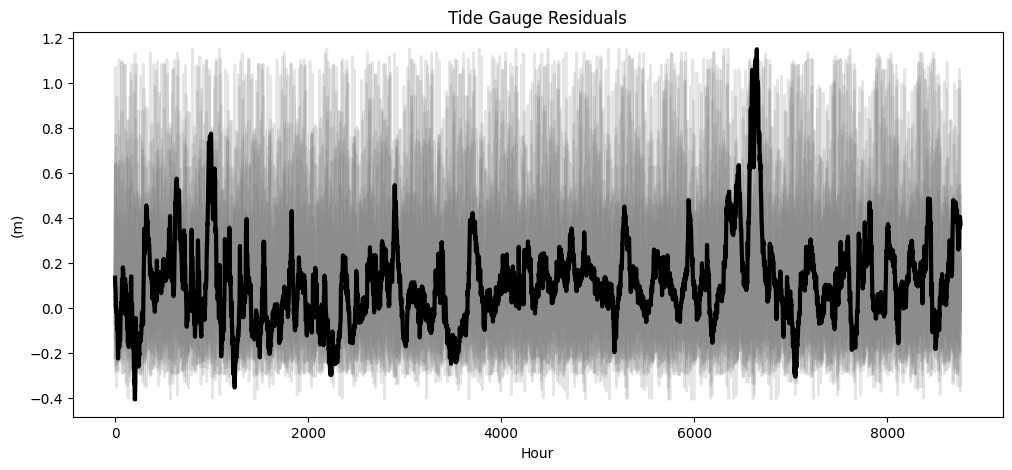

In [ ]:
plt.figure()
plt.xlabel("Hour")
plt.ylabel("(m)")
plt.title("Tide Gauge Residuals")
for i in range(10):
    label = "Replicate" if i == 0 else False
    plt.plot(weather_bootstrap[:, i], label=label, color='gray', alpha=0.2, linewidth=2)
plt.plot(dat['weather'], label="Data", color='black', linewidth=3)
plt.gcf().set_size_inches(12, 5)
plt.show()

In [ ]:
bootstrap_replicate = np.zeros((len(dat['weather']), n_boot))
for i in range(n_boot):
    bootstrap_replicate[:,i]= weather_bootstrap[:,i] + dat['harmonic']

In [ ]:
q_boot_coefficient = np.zeros([len(dat['weather']),2])
for i in range(len(dat['weather'])):
    q_boot_coefficient[i,:] = 2 * dat['gauge'][i] - np.quantile(bootstrap_replicate[i,:], [0.975, 0.025])

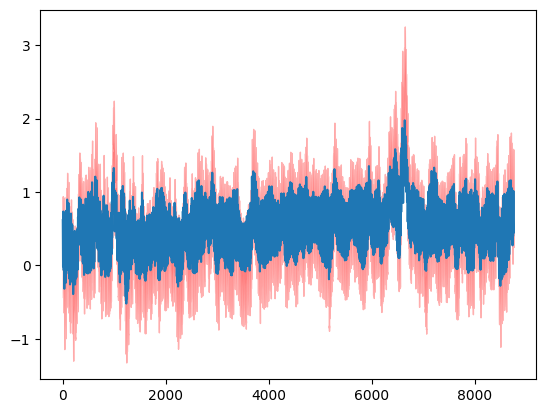

In [ ]:
plt.plot(dat['gauge'].index, dat['gauge'].values)
# plt.plot(x, λ, color = 'orange')
# plt.plot(dat['gauge'].index, means, color = 'red')
plt.fill_between(dat['gauge'].index, q_boot_coefficient[:,0], q_boot_coefficient[:,1], color='red', alpha=0.3, label = '90% Interval')
# plt.ylabel("Salamander Count")
# plt.xlabel("Percentage of Ground Cover (normalized)")
# plt.title("Salamander Count vs. Percent Ground Cover")
# plt.legend(['Data','Poisson Model','90% Interval' ])

In [ ]:
q_boot_coefficient[i,:] = 2 * dat['gauge'][i] - np.quantile(bootstrap_replicate[i,:], [0.975, 0.025])

In [ ]:
bias_corrected = np.zeros(len(dat['weather']))
for i in range(len(dat['weather'])):
    mean_boot = bootstrap_replicate[i,:].mean()
    bias = dat['gauge'][i] -  mean_boot
    bias_corrected[i] = dat['gauge'][i] + bias

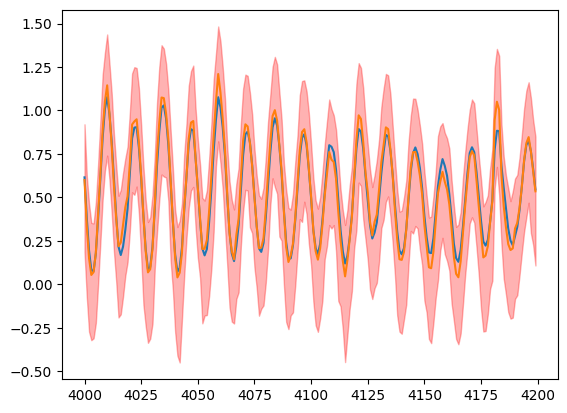

In [ ]:
s = 4000
e = 4200
plt.plot(dat['gauge'].index[s:e], dat['gauge'].values[s:e])
# plt.plot(x, λ, color = 'orange')
# plt.plot(dat['gauge'].index, means, color = 'red')
plt.fill_between(dat['gauge'].index[s:e], q_boot_coefficient[:,0][s:e], q_boot_coefficient[:,1][s:e], color='red', alpha=0.3, label = '90% Interval')
# plt.ylabel("Salamander Count")
# plt.xlabel("Percentage of Ground Cover (normalized)")
# plt.title("Salamander Count vs. Percent Ground Cover")
# plt.legend(['Data','Poisson Model','90% Interval' ])
plt.plot(dat['gauge'].index[s:e], bias_corrected[s:e])

Changing block length to 50

In [ ]:
# k is length of block
k = 50
n_blocks = len(dat['weather']) - k + 1
blocks = np.zeros([k, n_blocks])
for i in range(n_blocks):
    blocks[:, i] = dat['weather'][i:(k+i)]

blocks[:, 1:5]

array([[ 0.107,  0.097,  0.093,  0.093],
       [ 0.097,  0.093,  0.093,  0.08 ],
       [ 0.093,  0.093,  0.08 ,  0.068],
       [ 0.093,  0.08 ,  0.068,  0.031],
       [ 0.08 ,  0.068,  0.031,  0.005],
       [ 0.068,  0.031,  0.005,  0.011],
       [ 0.031,  0.005,  0.011,  0.012],
       [ 0.005,  0.011,  0.012,  0.001],
       [ 0.011,  0.012,  0.001, -0.002],
       [ 0.012,  0.001, -0.002, -0.014],
       [ 0.001, -0.002, -0.014, -0.013],
       [-0.002, -0.014, -0.013, -0.015],
       [-0.014, -0.013, -0.015, -0.02 ],
       [-0.013, -0.015, -0.02 , -0.019],
       [-0.015, -0.02 , -0.019, -0.031],
       [-0.02 , -0.019, -0.031, -0.071],
       [-0.019, -0.031, -0.071, -0.067],
       [-0.031, -0.071, -0.067, -0.084],
       [-0.071, -0.067, -0.084, -0.086],
       [-0.067, -0.084, -0.086, -0.092],
       [-0.084, -0.086, -0.092, -0.087],
       [-0.086, -0.092, -0.087, -0.081],
       [-0.092, -0.087, -0.081, -0.108],
       [-0.087, -0.081, -0.108, -0.126],
       [-0.081, 

In [ ]:
m

176

In [ ]:
m = int(np.ceil(len(dat['weather']) / k))
n_boot = 1000
weather_bootstrap = np.zeros((len(dat['weather']), n_boot))

for i in range(n_boot):
    block_sample_idx = np.random.choice(range(n_blocks), m, replace=True)
    weather_bootstrap[:, i] = np.concatenate(blocks[:, block_sample_idx])

ValueError: could not broadcast input array from shape (8800,) into shape (8760,)

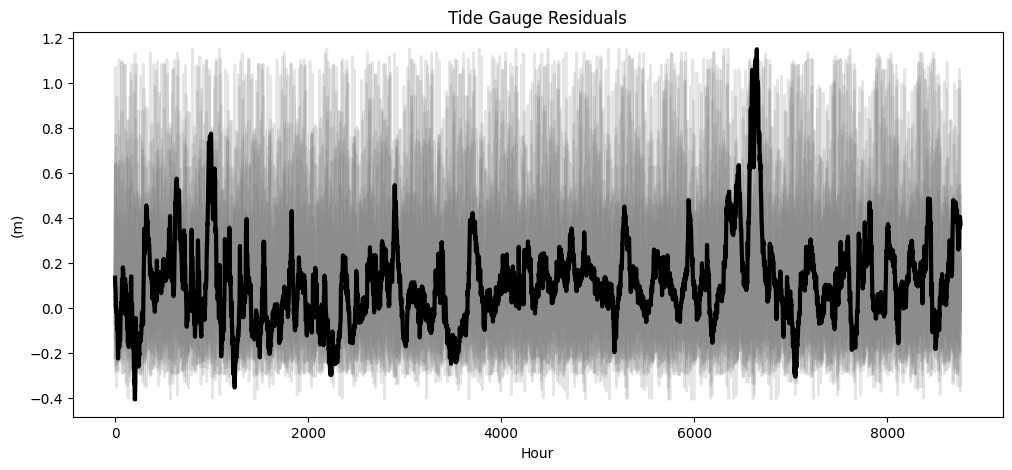

In [ ]:
plt.figure()
plt.xlabel("Hour")
plt.ylabel("(m)")
plt.title("Tide Gauge Residuals")
for i in range(10):
    label = "Replicate" if i == 0 else False
    plt.plot(weather_bootstrap[:, i], label=label, color='gray', alpha=0.2, linewidth=2)
plt.plot(dat['weather'], label="Data", color='black', linewidth=3)
plt.gcf().set_size_inches(12, 5)
plt.show()

In [ ]:
bootstrap_replicate = np.zeros((len(dat['weather']), n_boot))
for i in range(n_boot):
    bootstrap_replicate[:,i]= weather_bootstrap[:,i] + dat['harmonic']

In [ ]:
q_boot_coefficient = np.zeros([len(dat['weather']),2])
for i in range(len(dat['weather'])):
    q_boot_coefficient[i,:] = 2 * dat['gauge'][i] - np.quantile(bootstrap_replicate[i,:], [0.975, 0.025])

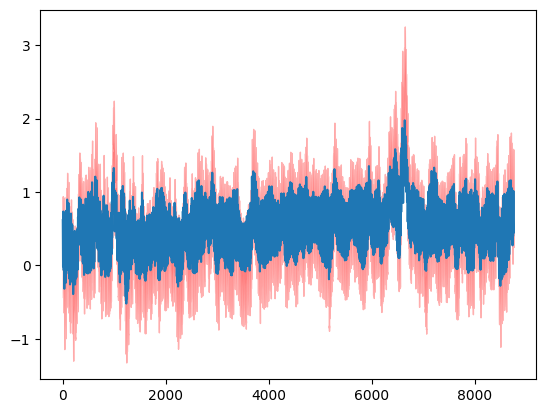

In [ ]:
plt.plot(dat['gauge'].index, dat['gauge'].values)
# plt.plot(x, λ, color = 'orange')
# plt.plot(dat['gauge'].index, means, color = 'red')
plt.fill_between(dat['gauge'].index, q_boot_coefficient[:,0], q_boot_coefficient[:,1], color='red', alpha=0.3, label = '90% Interval')
# plt.ylabel("Salamander Count")
# plt.xlabel("Percentage of Ground Cover (normalized)")
# plt.title("Salamander Count vs. Percent Ground Cover")
# plt.legend(['Data','Poisson Model','90% Interval' ])

In [ ]:
q_boot_coefficient[i,:] = 2 * dat['gauge'][i] - np.quantile(bootstrap_replicate[i,:], [0.975, 0.025])

In [ ]:
bias_corrected = np.zeros(len(dat['weather']))
for i in range(len(dat['weather'])):
    mean_boot = bootstrap_replicate[i,:].mean()
    bias = dat['gauge'][i] -  mean_boot
    bias_corrected[i] = dat['gauge'][i] + bias

In [ ]:
8760/k

461.05263157894734

In [ ]:
m

462

In [ ]:
np.random.choice(range(n_blocks), m, replace=True).shape

(462,)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

k = 19
n_blocks = len(dat['weather']) - k + 1
blocks = np.zeros((k, n_blocks))
for i in range(n_blocks):
    blocks[:, i] = dat['weather'][i:(k + i)]

blocks[:, :5]

m = int(np.ceil(len(dat['weather']) / k))
n_boot = 1000
surge_bootstrap = np.zeros((len(dat['weather']), n_boot))
for i in range(n_boot):
    block_sample_idx = np.random.choice(range(n_blocks), m, replace=True)
    surge_bootstrap[:, i] = np.concatenate(blocks[:, block_sample_idx])

# plt.figure()
# plt.plot(dat['weather'], color='black', linewidth=3, label="Data")
# plt.xlabel("Hour")
# plt.ylabel("(m)")
# plt.title("Tide Gauge Residuals")
# plt.alpha(0.5)
# plt.plot(surge_bootstrap[:, 0], color='blue', linewidth=3, label="Replicate", alpha=0.5)
# plt.show()

# plt.figure()
# plt.xlabel("Hour")
# plt.ylabel("(m)")
# plt.title("Tide Gauge Residuals")
# for i in range(10):
#     label = "Replicate" if i == 0 else False
#     plt.plot(surge_bootstrap[:, i], label=label, color='gray', alpha=0.2, linewidth=2)
# plt.plot(dat['weather'], label="Data", color='black', linewidth=3)
# plt.show()

ValueError: could not broadcast input array from shape (8778,) into shape (8760,)

In [ ]:
int(np.ceil(len(dat['weather']) / k))

462

References

https://www.codeconvert.ai/julia-to-python-converter